# Focal mechanisms, and the Kagan angle

"How different are these two earthquakes?" is a question with a standard
answer, and it is not obvious. Two focal mechanisms are two orientations in
space, and the rotation that carries one onto the other has **four** solutions,
not one. The smallest is the *Kagan angle*, after Kagan (1991), and it is the
number seismologists compare mechanisms with.

This notebook works through why there are four, what the smallest one means,
and the one thing it is most often used for: turning a catalogue into a
distance matrix and clustering it.

It also checks itself. Kagan's paper prints all four solutions for a worked
pair, and those numbers appear below as the target — so what you are reading is
verified against a 1991 publication rather than against this library's own
output.

Everything runs on data built in the notebook. `matplotlib` and `scipy` are
needed for the pictures and the clustering; `misah` is not.

## P and T, not nodal planes

A double-couple mechanism is usually quoted as two nodal planes, and there is a
catch: **nothing in the seismology says which of the two slipped**. They are
interchangeable, so a pair of planes is an ambiguous description.

What is unambiguous is the orthogonal triad the pair defines — **P** for the
axis of greatest shortening, **T** for greatest extension, and **B**, the null
axis at right angles to both. `misah` takes and returns mechanisms in that
form: four numbers, `P trend, P plunge, T trend, T plunge`.

`ptb_axes` converts from the other unambiguous form, a fault plane with the
slip observed on it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from misah.kernels import (ptb_axes, kagan_angles, kagan_angle_matrix,
                           focal_mechanism_rotations, rotate_focal_mechanism)

# (N, 4): right-hand-rule strike, dip, then slickenline trend and plunge --
# the same array invert_stress takes.
faults = np.array([
    [  0.0, 45.0,  90.0, 45.0],   # dips east, slips down-dip: normal
    [  0.0, 45.0, 270.0, -45.0],  # the same plane, slipping up-dip: reverse
    [ 90.0, 90.0,  90.0,  0.0],   # vertical, horizontal slip: strike-slip
])

axes = ptb_axes(faults)

for i, name in enumerate(["normal", "reverse", "strike-slip"]):
    print(f"{name:12}  P {axes['p'][i][0]:6.1f}/{axes['p'][i][1]:5.1f}"
          f"   T {axes['t'][i][0]:6.1f}/{axes['t'][i][1]:5.1f}"
          f"   B {axes['b'][i][0]:6.1f}/{axes['b'][i][1]:5.1f}")

normal        P   90.0/ 90.0   T   90.0/ -0.0   B    0.0/ -0.0
reverse       P   90.0/ -0.0   T   52.0/ 90.0   B  180.0/  0.0
strike-slip   P  225.0/ -0.0   T  135.0/ -0.0   B  180.0/ 90.0


Read those: the normal fault has P vertical and T horizontal, the reverse
fault the other way round, the strike-slip one has both horizontal and B
vertical. That is the Andersonian picture, and it falls straight out of the
geometry.

Read the **plunge**, not the trend, wherever an axis is steep. The reverse
fault's T comes back at trend 52 — a number with no meaning, because a vertical
axis has no bearing, and `atan2` has to return something. The same trap is
waiting in any map of S1 trend across a normal-faulting region, where it shows
up as a smooth rotation that is pure arithmetic.

**The sense of movement must be known.** `ptb_axes` refuses a slickenline whose
sense nobody could read, and the refusal is not fussiness: reversing an
undetermined slip exchanges P with T, so the same fault comes back as
shortening where the rock recorded extension. There is no defensible default.

Note this is stricter than `invert_stress`, which handles the same missing
information by taking its misfit modulo 180 degrees. No such modulo is
available here.

In [2]:
try:
    ptb_axes(faults[:1], senses=np.array([False]))
except ValueError as exc:
    print("refused:", exc)

refused: fault 0: the slickenline has no determined sense of movement, so P and T cannot be told apart


## Kagan's own example

His 1991 paper works one pair through and prints all four solutions. Here they
are, as the target.

In [3]:
# (P trend, P plunge, T trend, T plunge)
FIRST  = [232.0, 41.0, 120.0, 24.0]
SECOND = [ 51.0, 17.0, 295.0, 55.0]

# Kagan's published table: azimuth, colatitude from the downward vertical, and
# rotation angle. His parameterisation, left as printed.
PUBLISHED = [
    (24.8, 101.2, 102.8),
    (257.5, 79.7, 104.3),
    (144.8, 105.2, 124.1),
    (96.8, 16.7, 165.9),
]

found = focal_mechanism_rotations(*FIRST, *SECOND)

print(f"{'':4} {'computed':>28}   {'published':>28}")
for i, (az, colat, ang) in enumerate(PUBLISHED):
    print(f"  {i}  "
          f"{found['trend'][i]:8.3f} {found['plunge'][i]:8.3f} {found['angle_degrees'][i]:9.3f}   "
          f"{az:9.1f} {90.0 - colat:8.1f} {ang:9.1f}")

                         computed                      published
  0    24.915  -11.221   102.678        24.8    -11.2     102.8
  1   257.473   10.100   104.341       257.5     10.3     104.3
  2   144.919  -15.126   124.297       144.8    -15.2     124.1
  3    96.875   73.421   165.775        96.8     73.3     165.9


Agreement to about two tenths of a degree, which is what the published
values are quoted to.

Kagan gives the axis as a *colatitude from the downward vertical*, so the
plunge is its complement — that is the `90 - colat` above. And an axis with its
angle negated describes the same rotation from the other end, which is why one
row here may look reversed against the paper and still be the same answer.

## Why four, and not one

Because a double couple is **unchanged by a half turn about any of its own P, T
or B axes**. Turn the mechanism over and it radiates exactly the same thing. So
the base rotation composed with each of those three symmetries is an equally
correct answer to "what carries mechanism 1 onto mechanism 2".

This is checkable rather than something to take on faith: apply each of the
four and see where the first mechanism lands.

In [4]:
print("target:  P {:.1f}/{:.1f}   T {:.1f}/{:.1f}\n".format(*SECOND))

for i in range(4):
    turned = rotate_focal_mechanism(
        *FIRST,
        found["trend"][i], found["plunge"][i], found["angle_degrees"][i],
    )
    print(f"  turn by {found['angle_degrees'][i]:8.3f} about "
          f"{found['trend'][i]:7.2f}/{found['plunge'][i]:6.2f}"
          f"  ->  P {turned['p'][0]:6.2f}/{turned['p'][1]:5.2f}"
          f"   T {turned['t'][0]:6.2f}/{turned['t'][1]:5.2f}")

target:  P 51.0/17.0   T 295.0/55.0

  turn by  102.678 about   24.92/-11.22  ->  P  50.97/17.05   T 295.00/55.00
  turn by  104.341 about  257.47/ 10.10  ->  P  50.97/17.05   T 295.00/55.00
  turn by  124.297 about  144.92/-15.13  ->  P  50.97/17.05   T 295.00/55.00
  turn by  165.775 about   96.87/ 73.42  ->  P  50.97/17.05   T 295.00/55.00


All four land on the same place. They are four solutions, not one solution
and three artefacts.

(The recovered P reads 50.97/17.05 against the 51/17 given. Kagan's own P and T
are about a twentieth of a degree off exactly orthogonal, as measured axes
always are, and `misah` makes the triad exact by keeping T and moving P onto
the perpendicular. The 0.05 degrees is that correction, not an error.)

The first of the four is the **Kagan angle**. `kagan_angles` gives it directly,
elementwise over two catalogues.

In [5]:
print("Kagan angle:", kagan_angles(np.array([FIRST]), np.array([SECOND]))[0])
print("published minimum: 102.8")

Kagan angle: 102.67838808035445
published minimum: 102.8


## Where the mechanisms are, on a stereonet

Before going further it helps to see them. Lower-hemisphere equal-area, which
is about five lines of trigonometry and worth having in the notebook rather
than as a dependency.

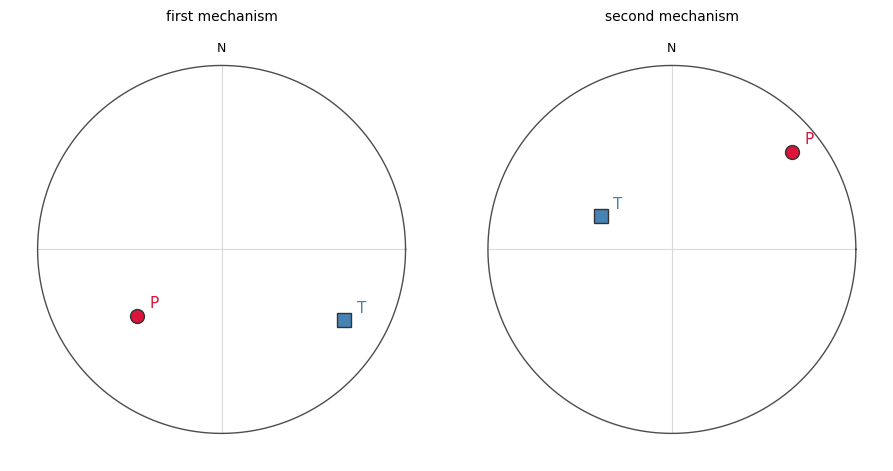

In [6]:
def lower_hemisphere(trend_deg, plunge_deg):
    """Equal-area (Schmidt) projection of a downward-pointing axis."""

    trend = np.radians(np.asarray(trend_deg, dtype=float))
    plunge = np.radians(np.asarray(plunge_deg, dtype=float))

    # An axis is undirected: flip anything pointing up into the lower
    # hemisphere, which is the half a stereonet shows.
    upward = plunge < 0
    trend = np.where(upward, trend + np.pi, trend)
    plunge = np.abs(plunge)

    radius = np.sqrt(2.0) * np.sin((np.pi / 2 - plunge) / 2)

    return radius * np.sin(trend), radius * np.cos(trend)


def stereonet(ax, title):
    circle = np.linspace(0, 2 * np.pi, 361)
    ax.plot(np.cos(circle), np.sin(circle), color="0.3", lw=1)
    ax.plot([0, 0], [-1, 1], color="0.85", lw=0.8, zorder=0)
    ax.plot([-1, 1], [0, 0], color="0.85", lw=0.8, zorder=0)
    ax.text(0, 1.06, "N", ha="center", va="bottom", fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.2)
    ax.axis("off")
    ax.set_title(title, fontsize=10)


fig, axs = plt.subplots(1, 2, figsize=(9, 4.6), constrained_layout=True)

for ax, mech, name in zip(axs, [FIRST, SECOND], ["first mechanism", "second mechanism"]):
    stereonet(ax, name)
    for (trend, plunge), label, colour, marker in [
        ((mech[0], mech[1]), "P", "crimson", "o"),
        ((mech[2], mech[3]), "T", "steelblue", "s"),
    ]:
        x, y = lower_hemisphere(trend, plunge)
        ax.plot(x, y, marker, color=colour, ms=10, mec="0.2")
        ax.annotate(label, (x, y), textcoords="offset points", xytext=(9, 6),
                    fontsize=11, color=colour)

plt.show()

## The 120-degree bound

The same fourfold symmetry that gives four answers also puts a ceiling on the
smallest one. Two arbitrary orientations in space can be up to 180 degrees
apart; two *double couples* can never exceed **120**.

That is the cheapest check there is on an implementation of this — a wrong set
of symmetry generators fails it immediately — and it is worth seeing rather
than being told.

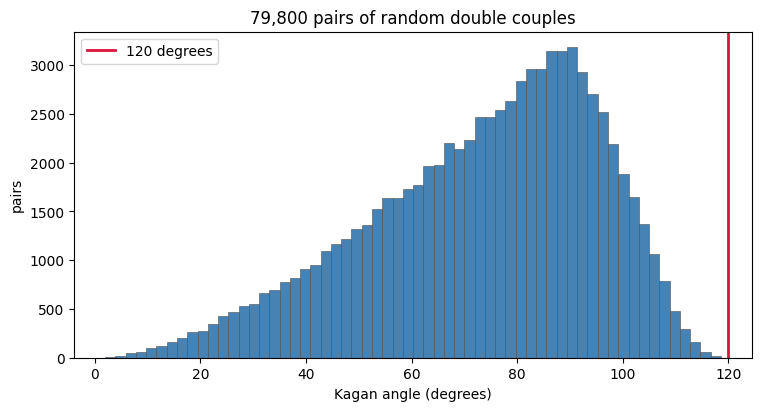

largest Kagan angle over 79,800 pairs: 118.5817


In [7]:
def random_mechanisms(count, seed=7):
    """A catalogue of proper double couples.

    Built from a T axis and a roll about it, not from two random axes: two
    random axes are essentially never orthogonal, and misah would refuse them.
    """
    rng = np.random.default_rng(seed)
    out = np.zeros((count, 4))

    for i in range(count):

        t_trend, t_plunge = rng.uniform(0, 360), rng.uniform(-90, 90)
        t = np.array([
            np.sin(np.radians(t_trend)) * np.cos(np.radians(t_plunge)),
            np.cos(np.radians(t_trend)) * np.cos(np.radians(t_plunge)),
            -np.sin(np.radians(t_plunge)),
        ])

        helper = np.array([0, 0, 1.0]) if abs(t[2]) < 0.9 else np.array([1.0, 0, 0])
        u = np.cross(t, helper); u /= np.linalg.norm(u)
        v = np.cross(t, u)

        roll = np.radians(rng.uniform(0, 360))
        p = u * np.cos(roll) + v * np.sin(roll)

        out[i] = [
            np.degrees(np.arctan2(p[0], p[1])) % 360.0,
            np.degrees(np.arcsin(-p[2])),
            t_trend,
            t_plunge,
        ]

    return out


catalogue = random_mechanisms(400)
angles = kagan_angle_matrix(catalogue)
off_diagonal = angles[np.triu_indices(len(catalogue), k=1)]

fig, ax = plt.subplots(figsize=(7.5, 4), constrained_layout=True)
ax.hist(off_diagonal, bins=60, color="steelblue", edgecolor="0.3", linewidth=0.4)
ax.axvline(120, color="crimson", lw=2, label="120 degrees")
ax.set_xlabel("Kagan angle (degrees)")
ax.set_ylabel("pairs")
ax.set_title(f"{len(off_diagonal):,} pairs of random double couples")
ax.legend()
plt.show()

print(f"largest Kagan angle over {len(off_diagonal):,} pairs: {off_diagonal.max():.4f}")

The distribution rises to a broad maximum near 90 degrees and dies at
120 — the largest of nearly eighty thousand pairs falling about a degree and a
half short of the bound. Nothing was clipped or truncated: that is simply where
the geometry ends.

## The reason to want a matrix

`kagan_angle_matrix` gives every pairwise angle in a catalogue at once. It is
symmetric with a zero diagonal, which is to say it is a **distance matrix** —
and that is what makes it useful, because a distance matrix goes straight into
a clustering routine.

This is also why the function is in Rust rather than a numpy loop: a catalogue
against itself is `N²/2` rotations, each a handful of quaternion products.
Trivial once, ruinous a million times in Python.

In [8]:
import time

for n in [200, 400, 800]:
    sample = random_mechanisms(n, seed=11)
    start = time.perf_counter()
    kagan_angle_matrix(sample)
    elapsed = time.perf_counter() - start
    print(f"{n:4d} mechanisms  ({n*(n-1)//2:>7,} pairs)  {elapsed*1000:7.1f} ms")

 200 mechanisms  ( 19,900 pairs)      3.6 ms
 400 mechanisms  ( 79,800 pairs)     14.6 ms
 800 mechanisms  (319,600 pairs)     55.6 ms


### Clustering a catalogue

A synthetic catalogue with two populations: a normal-faulting set and a
strike-slip set, each with a few degrees of scatter, shuffled together. The
question a clustering answers is whether the Kagan angle can tell them apart
without being told there are two.

In [9]:
def scattered_about(strike, dip, rake_trend, rake_plunge, count, spread, seed):
    """A population of mechanisms near one orientation."""

    rng = np.random.default_rng(seed)
    base = ptb_axes(np.array([[strike, dip, rake_trend, rake_plunge]]))
    p, t = base["p"][0], base["t"][0]

    out = np.zeros((count, 4))
    for i in range(count):
        # Perturb the T axis, then rebuild P at right angles to it, so every
        # row is a proper triad rather than two independently wobbled axes.
        t_trend = t[0] + rng.normal(0, spread)
        t_plunge = np.clip(t[1] + rng.normal(0, spread), -90, 90)

        tv = np.array([
            np.sin(np.radians(t_trend)) * np.cos(np.radians(t_plunge)),
            np.cos(np.radians(t_trend)) * np.cos(np.radians(t_plunge)),
            -np.sin(np.radians(t_plunge)),
        ])
        pv = np.array([
            np.sin(np.radians(p[0])) * np.cos(np.radians(p[1])),
            np.cos(np.radians(p[0])) * np.cos(np.radians(p[1])),
            -np.sin(np.radians(p[1])),
        ])
        pv = pv - tv * np.dot(pv, tv)
        pv /= np.linalg.norm(pv)

        out[i] = [
            np.degrees(np.arctan2(pv[0], pv[1])) % 360.0,
            np.degrees(np.arcsin(-pv[2])),
            t_trend, t_plunge,
        ]

    return out


normal = scattered_about(0.0, 45.0, 90.0, 45.0, 60, spread=8.0, seed=1)
strike_slip = scattered_about(90.0, 90.0, 90.0, 0.0, 60, spread=8.0, seed=2)

mixed = np.vstack([normal, strike_slip])
truth = np.array([0] * len(normal) + [1] * len(strike_slip))

order = np.random.default_rng(3).permutation(len(mixed))
mixed, truth = mixed[order], truth[order]

distances = kagan_angle_matrix(mixed)
print("distance matrix", distances.shape,
      "  symmetric:", np.array_equal(distances, distances.T))

distance matrix (120, 120)   symmetric: True


two clusters recovered, agreeing with the truth on 100.0% of the catalogue


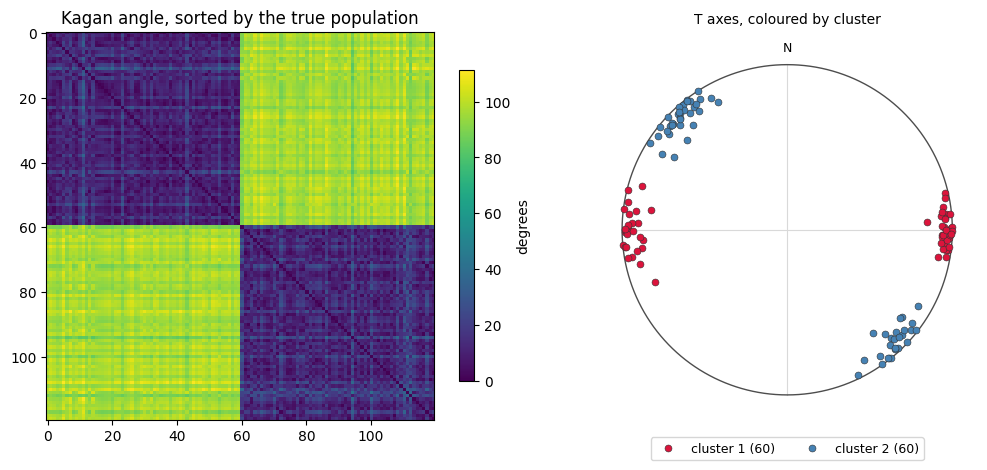

In [10]:
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform

# `linkage` wants the condensed upper triangle, which is exactly what a
# symmetric zero-diagonal matrix reduces to.
tree = linkage(squareform(distances, checks=False), method="average")
labels = fcluster(tree, t=2, criterion="maxclust")

agreement = max(
    (labels == 1).astype(int).__eq__(truth).mean(),
    (labels == 2).astype(int).__eq__(truth).mean(),
)
print(f"two clusters recovered, agreeing with the truth on {agreement:.1%} of the catalogue")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)

by_truth = np.argsort(truth, kind="stable")
im = axs[0].imshow(distances[np.ix_(by_truth, by_truth)], cmap="viridis")
axs[0].set_title("Kagan angle, sorted by the true population")
fig.colorbar(im, ax=axs[0], label="degrees", shrink=0.8)

stereonet(axs[1], "T axes, coloured by cluster")
for cluster, colour in [(1, "crimson"), (2, "steelblue")]:
    rows = mixed[labels == cluster]
    x, y = lower_hemisphere(rows[:, 2], rows[:, 3])
    axs[1].plot(x, y, "o", color=colour, ms=5, mec="0.2", mew=0.4,
                label=f"cluster {cluster} ({len(rows)})")
axs[1].legend(loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)

plt.show()

Two blocks on the diagonal of the matrix — dark within each population,
bright between them — and the clustering recovers them exactly, without being
told the populations exist. That is the whole workflow: mechanisms in, distance
matrix out, structure found.

Each colour appears as **two** blobs on the stereonet, and that is a property of
the plot rather than of the data. These T axes are nearly horizontal, so both
ends of the axis sit on the rim; a scatter of a few degrees sends some rows just
above the horizontal and some just below, and the projection folds the upward
ones to the opposite side of the net. The two blobs of one colour are the two
ends of the same population. It is worth knowing before reading a stereonet of
shallow axes as two groups.

## One caveat worth more than the rest

**P and T are not stress axes.** They are kinematic: pinned at exactly 45
degrees to the fault plane by the construction that produces them, whatever the
rock's friction actually is. They coincide with the principal stresses only
under Anderson's assumption, which real rock keeps roughly at best.

Averaging P and T axes over a region and calling the result a stress field is
the standard way of publishing a *strain* field with the wrong label on it. If
you want stress, `invert_stress` and `stress_field` are what solve for it — see
`02_stress_field.ipynb` — and they take fault-slip data rather than
mechanisms.

## What to carry away

- A mechanism crosses as **P trend, P plunge, T trend, T plunge**. Nodal planes
  are ambiguous; this is not.
- **The sense of slip must be known** to get P and T from a fault. Without it
  the two exchange, and extension is reported as shortening.
- There are **four rotations**, not one, and all four are correct. The smallest
  is the Kagan angle.
- **Nothing exceeds 120 degrees.** If your implementation produces 150, its
  symmetry generators are wrong.
- `kagan_angle_matrix` is a **distance matrix** — symmetric, zero diagonal —
  and exists to be clustered.
- **P and T are kinematic, not stress.**